# Feature Selection FPT

In [120]:
stock_code = "FPT"

In [121]:
stock_code = str.lower(stock_code)

## Install libraries

In [122]:
# !pip install -r ../../requirements.txt

## Import libraries

In [123]:
import os
import sys
import pandas as pd

# go one level up from where the notebook is running
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger
from feature_selector.feature_selector import (
    FeatureSelector,
    summarize_feature_importances,
    plot_final_feature_importances,
    plot_feature_correlation_heatmap,
    drop_low_importance_correlated_features,
    get_important_features_df,
    get_feature_correlation_df,
)
from utils.constants import *
from utils.enums import *
from utils.utils import cast_columns_to_float
from dtos.tabular_database_driver_dtos.tabular_database_driver_dtos import *
from tabular_database_driver.postgre_sql_driver import PostgreSQLDriver
from dtos.tabular_database_driver_dtos.postgre_sql_connection_dto import (
    PostgreSQLConnectionDto,
)
from matplotlib.pylab import ceil

## Initialize the Logger

In [124]:
my_logger = Logger(
    file_name=f"{FEATURE_SELECTION_LOG_FILE_BASE}/{stock_code}_feature_selection"
)

## List all FeatureSelectorType

In [125]:
print([member.name for member in FeatureSelectorType])

['XGB_REGRESSOR', 'LASSO', 'ELASTIC_NET', 'XGB_SHAP']


## Initialize the Database Driver

In [126]:
database_driver = PostgreSQLDriver(logger=my_logger)

connection_model = PostgreSQLConnectionDto(
    logger=my_logger,
    host=os.getenv("POSTGRES_HOST"),
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD"),
    port=os.getenv("POSTGRES_PORT"),
    database=os.getenv("GOLD_POSTGRES_DATABASE"),
)

database_driver.connect(connection_model)

<DatabaseExecutionStatus.SUCCESS: 'success'>

## Parameters

In [127]:
normalized_importances_dict = {}

In [128]:
output_column_name = "close"

In [129]:
train_ratio = DEFAULT_TRAIN_RATIO
input_window_size = DEFAULT_INPUT_WINDOW_SIZE
forecast_horizon_size = DEFAULT_FORECAST_HORIZON_SIZE

## Load data

In [130]:
df = database_driver.select(
    schema_name=Schema.ENTERPRISE.value,
    table_name=f"unified_{stock_code}",
)
df = cast_columns_to_float(df)

In [131]:
df

,date,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,...,week_of_month,half_of_year,is_weekend,season,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,2006-12-13,7.552055,14.203619,2888.656452,92.003231,253.595161,16.025534,22.747446,11.056317,474.899933,...,2.0,2.0,0.0,1.0,-2.449294e-16,1.000000,0.974928,-0.222521,-0.304921,0.952378
1,2006-12-14,7.553425,14.216089,2898.413871,92.084006,265.067097,16.039604,22.767417,11.066024,475.316878,...,2.0,2.0,0.0,1.0,-2.449294e-16,1.000000,0.433884,-0.900969,-0.288482,0.957485
2,2006-12-15,7.554795,14.228559,2908.171290,92.164782,276.539032,16.053674,22.787388,11.075731,475.733823,...,3.0,2.0,0.0,1.0,-2.449294e-16,1.000000,-0.433884,-0.900969,-0.271958,0.962309
3,2024-05-31,6.511319,93.751366,780.000000,700.000000,70.000000,165.000000,260.000000,185.000000,2400.000000,...,5.0,1.0,0.0,2.0,5.000000e-01,-0.866025,-0.433884,-0.900969,0.501242,-0.865307
4,2006-12-18,7.558904,14.265970,2937.443548,92.407108,310.954839,16.095883,22.847303,11.104852,476.984656,...,3.0,2.0,0.0,1.0,-2.449294e-16,1.000000,0.000000,1.000000,-0.221922,0.975065
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4610,2025-01-10,7.481111,88.845806,841.658065,577.078387,49.097742,289.532258,240.948710,232.428065,2184.285484,...,2.0,1.0,0.0,1.0,5.000000e-01,0.866025,-0.433884,-0.900969,0.171293,0.985220
4611,2025-01-20,7.412222,81.271613,809.416129,576.226774,43.865484,280.564516,234.987419,226.486129,2102.520968,...,3.0,1.0,0.0,1.0,5.000000e-01,0.866025,0.000000,1.000000,0.337523,0.941317
4612,2025-01-21,7.405333,80.514194,806.191935,576.141613,43.342258,279.667742,234.391290,225.891935,2094.344516,...,3.0,1.0,0.0,1.0,5.000000e-01,0.866025,0.781831,0.623490,0.353676,0.935368
4613,2025-01-22,7.398444,79.756774,802.967742,576.056452,42.819032,278.770968,233.795161,225.297742,2086.168065,...,4.0,1.0,0.0,1.0,5.000000e-01,0.866025,0.974928,-0.222521,0.369725,0.929141


In [132]:
# Sort by date or time index if available
if "date" in df.columns:
    df = df.sort_values("date").reset_index(drop=True)
else:
    df = df.reset_index(drop=True)

# --- Adjusted split index logic ---
split_index = ceil(len(df) * train_ratio)
split_index -= input_window_size  # ensure full input window fits

# Make split_index divisible by forecast_horizon_size
remainder = split_index % forecast_horizon_size
if remainder != 0:
    split_index -= remainder

# Guard against invalid split index
if split_index <= 0 or split_index >= len(df):
    raise ValueError(
        f"Adjusted split_index ({split_index}) is invalid for data length {len(df)}"
    )

# Add back input windwo size to split_index
split_index += input_window_size
split_index = int(split_index)
split_index

4140

In [133]:
# --- Split train/test ---
train = df.iloc[:split_index].reset_index(drop=True)
test = df.iloc[split_index:].reset_index(drop=True)

In [134]:
train

,date,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,...,week_of_month,half_of_year,is_weekend,season,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,2006-12-13,7.552055,14.203619,2888.656452,92.003231,253.595161,16.025534,22.747446,11.056317,474.899933,...,2.0,2.0,0.0,1.0,-2.449294e-16,1.000000,0.974928,-0.222521,-0.304921,0.952378
1,2006-12-14,7.553425,14.216089,2898.413871,92.084006,265.067097,16.039604,22.767417,11.066024,475.316878,...,2.0,2.0,0.0,1.0,-2.449294e-16,1.000000,0.433884,-0.900969,-0.288482,0.957485
2,2006-12-15,7.554795,14.228559,2908.171290,92.164782,276.539032,16.053674,22.787388,11.075731,475.733823,...,3.0,2.0,0.0,1.0,-2.449294e-16,1.000000,-0.433884,-0.900969,-0.271958,0.962309
3,2006-12-18,7.558904,14.265970,2937.443548,92.407108,310.954839,16.095883,22.847303,11.104852,476.984656,...,3.0,2.0,0.0,1.0,-2.449294e-16,1.000000,0.000000,1.000000,-0.221922,0.975065
4,2006-12-19,7.560274,14.278440,2947.200968,92.487884,322.426774,16.109953,22.867274,11.114559,477.401601,...,3.0,2.0,0.0,1.0,-2.449294e-16,1.000000,0.781831,0.623490,-0.205104,0.978740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4135,2023-07-25,4.463370,89.873117,790.322581,409.677419,55.193548,194.193548,135.483871,225.806452,2932.258065,...,4.0,2.0,0.0,3.0,-5.000000e-01,-0.866025,0.781831,0.623490,-0.393590,-0.919286
4136,2023-07-26,4.476304,89.885587,791.935484,408.064516,55.161290,195.161290,132.903226,224.838710,2943.548387,...,4.0,2.0,0.0,3.0,-5.000000e-01,-0.866025,0.974928,-0.222521,-0.409356,-0.912375
4137,2023-07-27,4.489239,89.898057,793.548387,406.451613,55.129032,196.129032,130.322581,223.870968,2954.838710,...,4.0,2.0,0.0,3.0,-5.000000e-01,-0.866025,0.433884,-0.900969,-0.425000,-0.905193
4138,2023-07-28,4.502174,89.910528,795.161290,404.838710,55.096774,197.096774,127.741935,222.903226,2966.129032,...,4.0,2.0,0.0,3.0,-5.000000e-01,-0.866025,-0.433884,-0.900969,-0.440519,-0.897743


In [135]:
test

,date,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,...,week_of_month,half_of_year,is_weekend,season,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,2023-08-01,4.553913,89.960409,799.354839,406.451613,54.903226,200.000,123.225806,220.483871,2995.161290,...,1.0,2.0,0.0,3.0,-8.660254e-01,-0.5,0.781831,0.623490,-0.501242,-0.865307
1,2023-08-02,4.566848,89.972879,798.709677,412.903226,54.806452,200.000,126.451613,220.967742,2990.322581,...,1.0,2.0,0.0,3.0,-8.660254e-01,-0.5,0.974928,-0.222521,-0.516062,-0.856551
2,2023-08-03,4.579783,89.985349,798.064516,419.354839,54.709677,200.000,129.677419,221.451613,2985.483871,...,1.0,2.0,0.0,3.0,-8.660254e-01,-0.5,0.433884,-0.900969,-0.530730,-0.847541
3,2023-08-04,4.592717,89.997819,797.419355,425.806452,54.612903,200.000,132.903226,221.935484,2980.645161,...,1.0,2.0,0.0,3.0,-8.660254e-01,-0.5,-0.433884,-0.900969,-0.545240,-0.838280
4,2023-08-07,4.631522,90.035230,795.483871,445.161290,54.322581,200.000,142.580645,223.387097,2966.129032,...,1.0,2.0,0.0,3.0,-8.660254e-01,-0.5,0.000000,1.000000,-0.587785,-0.809017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
470,2025-06-24,7.892088,106.580000,924.416000,588.792000,71.022000,298.416,222.118000,228.012000,2728.292000,...,4.0,1.0,0.0,3.0,1.224647e-16,-1.0,0.781831,0.623490,0.128748,-0.991677
471,2025-06-25,7.903407,106.483333,921.386667,591.150000,70.561667,294.125,221.931667,228.783333,2717.668333,...,4.0,1.0,0.0,3.0,1.224647e-16,-1.0,0.974928,-0.222521,0.111659,-0.993747
472,2025-06-26,7.914725,106.386667,918.357333,593.508000,70.101333,289.834,221.745333,229.554667,2707.044667,...,4.0,1.0,0.0,3.0,1.224647e-16,-1.0,0.433884,-0.900969,0.094537,-0.995521
473,2025-06-27,7.926044,106.290000,915.328000,595.866000,69.641000,285.543,221.559000,230.326000,2696.421000,...,4.0,1.0,0.0,3.0,1.224647e-16,-1.0,-0.433884,-0.900969,0.077386,-0.997001


In [136]:
train = train.drop(columns=["date"])

In [137]:
train

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,week_of_month,half_of_year,is_weekend,season,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,7.552055,14.203619,2888.656452,92.003231,253.595161,16.025534,22.747446,11.056317,474.899933,747.464516,...,2.0,2.0,0.0,1.0,-2.449294e-16,1.000000,0.974928,-0.222521,-0.304921,0.952378
1,7.553425,14.216089,2898.413871,92.084006,265.067097,16.039604,22.767417,11.066024,475.316878,750.208710,...,2.0,2.0,0.0,1.0,-2.449294e-16,1.000000,0.433884,-0.900969,-0.288482,0.957485
2,7.554795,14.228559,2908.171290,92.164782,276.539032,16.053674,22.787388,11.075731,475.733823,752.952903,...,3.0,2.0,0.0,1.0,-2.449294e-16,1.000000,-0.433884,-0.900969,-0.271958,0.962309
3,7.558904,14.265970,2937.443548,92.407108,310.954839,16.095883,22.847303,11.104852,476.984656,761.185484,...,3.0,2.0,0.0,1.0,-2.449294e-16,1.000000,0.000000,1.000000,-0.221922,0.975065
4,7.560274,14.278440,2947.200968,92.487884,322.426774,16.109953,22.867274,11.114559,477.401601,763.929677,...,3.0,2.0,0.0,1.0,-2.449294e-16,1.000000,0.781831,0.623490,-0.205104,0.978740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4135,4.463370,89.873117,790.322581,409.677419,55.193548,194.193548,135.483871,225.806452,2932.258065,93.548387,...,4.0,2.0,0.0,3.0,-5.000000e-01,-0.866025,0.781831,0.623490,-0.393590,-0.919286
4136,4.476304,89.885587,791.935484,408.064516,55.161290,195.161290,132.903226,224.838710,2943.548387,91.290323,...,4.0,2.0,0.0,3.0,-5.000000e-01,-0.866025,0.974928,-0.222521,-0.409356,-0.912375
4137,4.489239,89.898057,793.548387,406.451613,55.129032,196.129032,130.322581,223.870968,2954.838710,89.032258,...,4.0,2.0,0.0,3.0,-5.000000e-01,-0.866025,0.433884,-0.900969,-0.425000,-0.905193
4138,4.502174,89.910528,795.161290,404.838710,55.096774,197.096774,127.741935,222.903226,2966.129032,86.774194,...,4.0,2.0,0.0,3.0,-5.000000e-01,-0.866025,-0.433884,-0.900969,-0.440519,-0.897743


## Feature Selection Type: XGB Regressor

In [138]:
xgb_feature_selector = FeatureSelector(
    logger=my_logger,
    stock_code=stock_code,
    feature_selector_type=FeatureSelectorType.XGB_REGRESSOR,
)

In [139]:
xgb_feature_selector.fit(dataframe=train, target_column=output_column_name)

In [140]:
normalized_importances_dict[FeatureSelectorType.XGB_REGRESSOR.value["name"]] = (
    xgb_feature_selector.get_feature_importances()
)
xgb_feature_selector.get_feature_importances()

,feature,importance
0,year,1.000000
1,labor_female,0.165897
2,open,0.128207
3,xpi_animal_feed_and_raw_materials,0.076720
4,low,0.032208
...,...,...
199,nasdaq_100_low,0.000000
200,nasdaq_100_volume,0.000000
201,mip_chemical_fertilizers,0.000000
202,mip_canned_seafood,0.000000


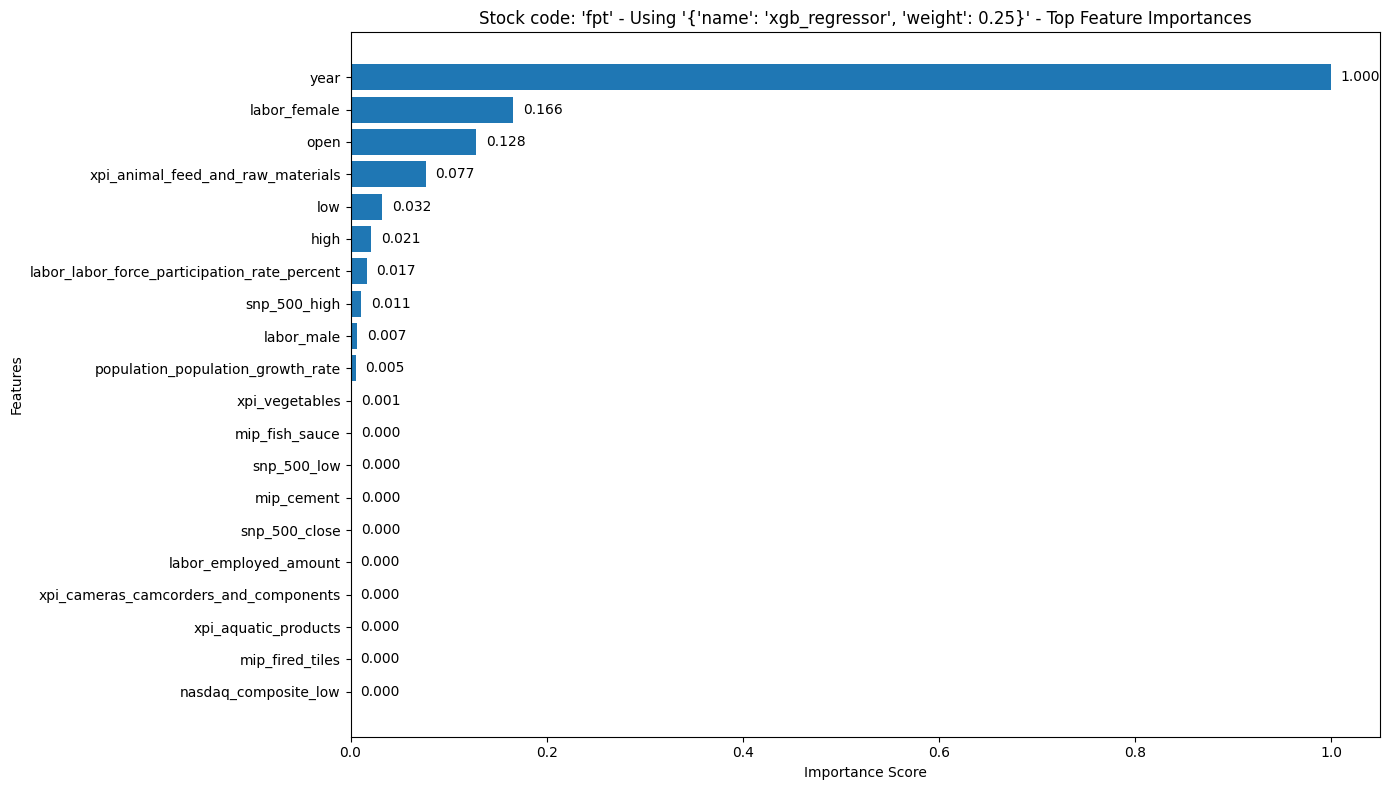

In [141]:
xgb_feature_selector.plot_feature_importances()

## Feature Selection Type: LASSO

In [142]:
lasso_feature_selector = FeatureSelector(
    logger=my_logger,
    stock_code=stock_code,
    feature_selector_type=FeatureSelectorType.LASSO,
)

In [143]:
lasso_feature_selector.fit(dataframe=train, target_column=output_column_name)

d:\GIT\master-thesis\mt_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.660e+02, tolerance: 9.335e+01
  model = cd_fast.enet_coordinate_descent(


In [144]:
normalized_importances_dict[FeatureSelectorType.LASSO.value["name"]] = (
    lasso_feature_selector.get_feature_importances()
)
lasso_feature_selector.get_feature_importances()

,feature,importance
0,open,1.000000
1,high,0.294097
2,ipv_rolled_steel,0.003338
3,xpi_raw_plastics,0.001632
4,hnx_index_close,0.000455
...,...,...
199,mip_beer,0.000000
200,mip_canned_fruits_and_nuts,0.000000
201,mip_canned_seafood,0.000000
202,mip_cast_or_other_rough_iron_and_steel,0.000000


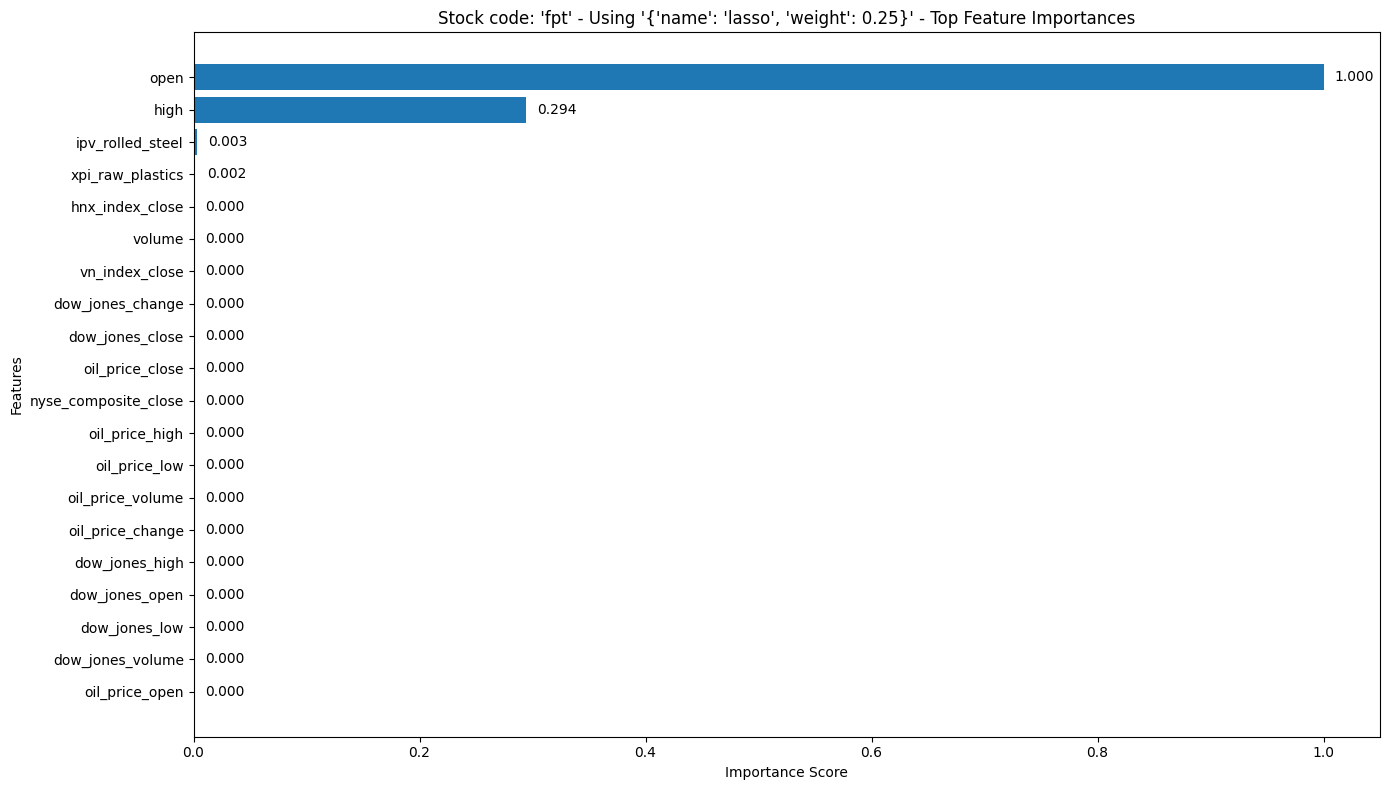

In [145]:
lasso_feature_selector.plot_feature_importances()

## Feature Selection Type: ELASTIC_NET

In [146]:
elastic_net_feature_selector = FeatureSelector(
    logger=my_logger,
    stock_code=stock_code,
    feature_selector_type=FeatureSelectorType.ELASTIC_NET,
)

In [147]:
elastic_net_feature_selector.fit(dataframe=train, target_column=output_column_name)

In [148]:
normalized_importances_dict[FeatureSelectorType.ELASTIC_NET.value["name"]] = (
    elastic_net_feature_selector.get_feature_importances()
)
elastic_net_feature_selector.get_feature_importances()

,feature,importance
0,high,1.000000
1,low,0.998149
2,open,0.961790
3,mip_domestic_ceramics,0.307326
4,population_population_growth_rate,0.133395
...,...,...
199,mip_fiber_cement_roofing_sheets,0.000000
200,mip_fired_bricks,0.000000
201,mip_fired_tiles,0.000000
202,mip_fish_sauce,0.000000


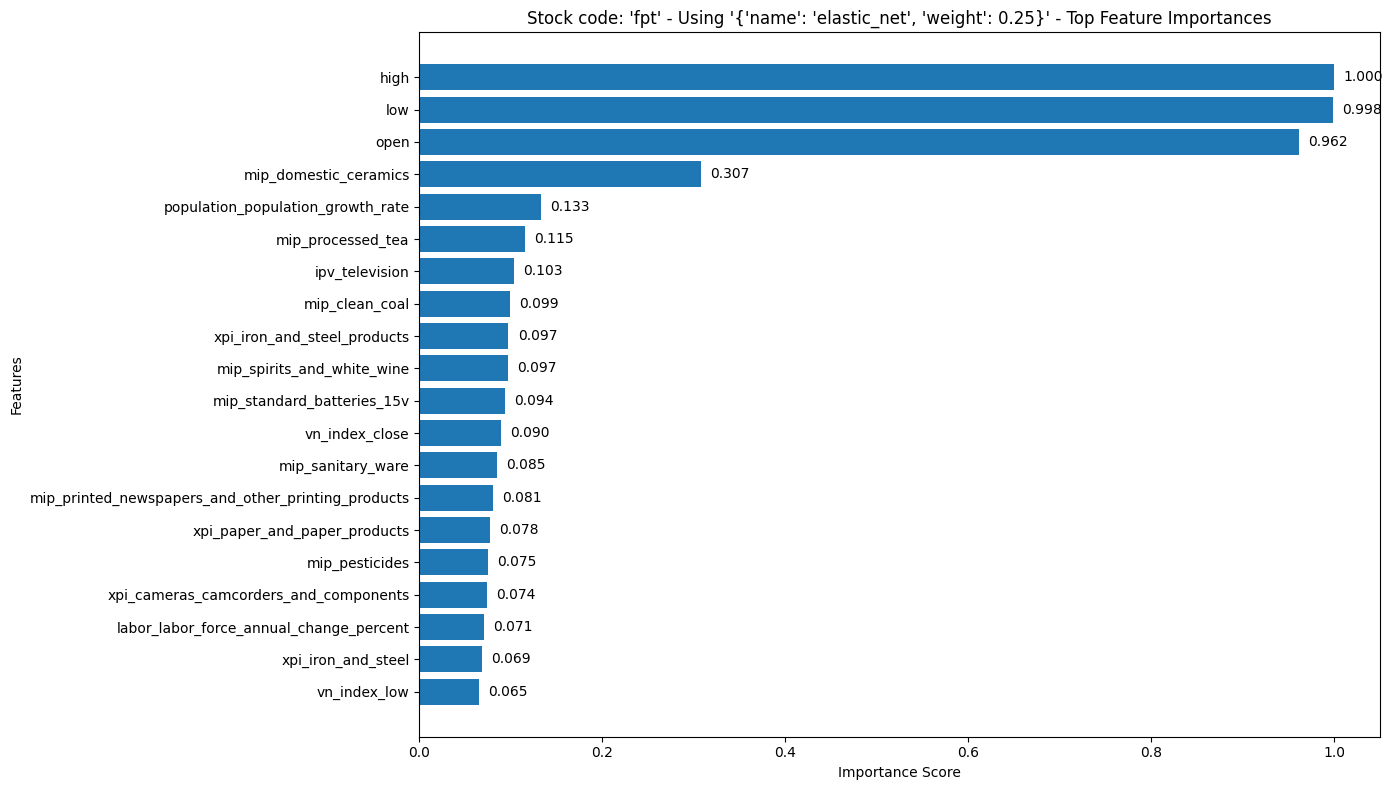

In [149]:
elastic_net_feature_selector.plot_feature_importances()

## Feature Selection Type: XGB_SHAP

In [150]:
xgb_shap_feature_selector = FeatureSelector(
    logger=my_logger,
    stock_code=stock_code,
    feature_selector_type=FeatureSelectorType.XGB_SHAP,
)

In [151]:
xgb_shap_feature_selector.fit(dataframe=train, target_column=output_column_name)

In [152]:
normalized_importances_dict[FeatureSelectorType.XGB_SHAP.value["name"]] = (
    xgb_shap_feature_selector.get_feature_importances()
)
xgb_shap_feature_selector.get_feature_importances()

,feature,importance
0,low,1.000000
1,high,0.943183
2,labor_female,0.285730
3,year,0.231804
4,open,0.168308
...,...,...
199,nasdaq_100_volume,0.000000
200,mip_crude_oil_extraction,0.000000
201,mip_chemical_fertilizers,0.000000
202,mip_canned_seafood,0.000000


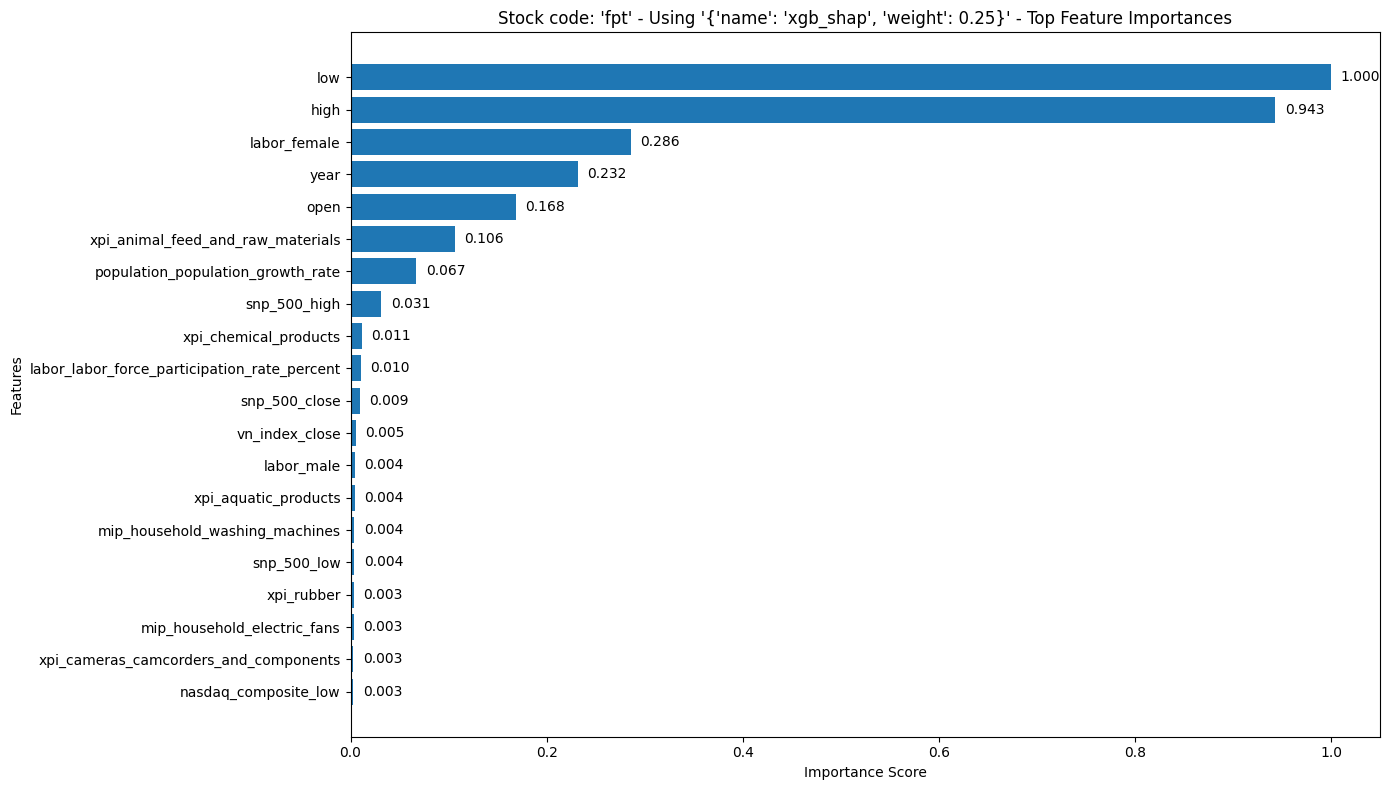

In [153]:
xgb_shap_feature_selector.plot_feature_importances()

## Normalize Feature Selection Types

In [154]:
weights = {
    FeatureSelectorType.XGB_REGRESSOR.value[
        "name"
    ]: FeatureSelectorType.XGB_REGRESSOR.value["weight"],
    FeatureSelectorType.LASSO.value["name"]: FeatureSelectorType.LASSO.value["weight"],
    FeatureSelectorType.ELASTIC_NET.value[
        "name"
    ]: FeatureSelectorType.ELASTIC_NET.value["weight"],
    FeatureSelectorType.XGB_SHAP.value["name"]: FeatureSelectorType.XGB_SHAP.value[
        "weight"
    ],
}
weights

{'xgb_regressor': 0.25, 'lasso': 0.25, 'elastic_net': 0.25, 'xgb_shap': 0.25}

In [155]:
final_feature_importance_df = summarize_feature_importances(
    normalized_importances_dict=normalized_importances_dict, weights=weights
)
final_feature_importance_df

,feature,xgb_regressor,lasso,elastic_net,xgb_shap,xgb_regressor_weighted,lasso_weighted,elastic_net_weighted,xgb_shap_weighted,final_importance
0,high,0.021047,0.294097,1.000000,0.943183,0.005262,0.073524,0.250000,0.235796,0.564582
1,open,0.128207,1.000000,0.961790,0.168308,0.032052,0.250000,0.240447,0.042077,0.564576
2,low,0.032208,0.000000,0.998149,1.000000,0.008052,0.000000,0.249537,0.250000,0.507589
3,year,1.000000,0.000000,0.000000,0.231804,0.250000,0.000000,0.000000,0.057951,0.307951
4,labor_female,0.165897,0.000000,0.000000,0.285730,0.041474,0.000000,0.000000,0.071432,0.112907
...,...,...,...,...,...,...,...,...,...,...
199,mip_paper_and_cardboard,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
200,mip_milled_rice,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
201,mip_household_refrigerators_and_freezers,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
202,quarter,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


✅ Plot saved to: d:\GIT\master-thesis\logs\feature_selection\fpt_final_feature_importances.png


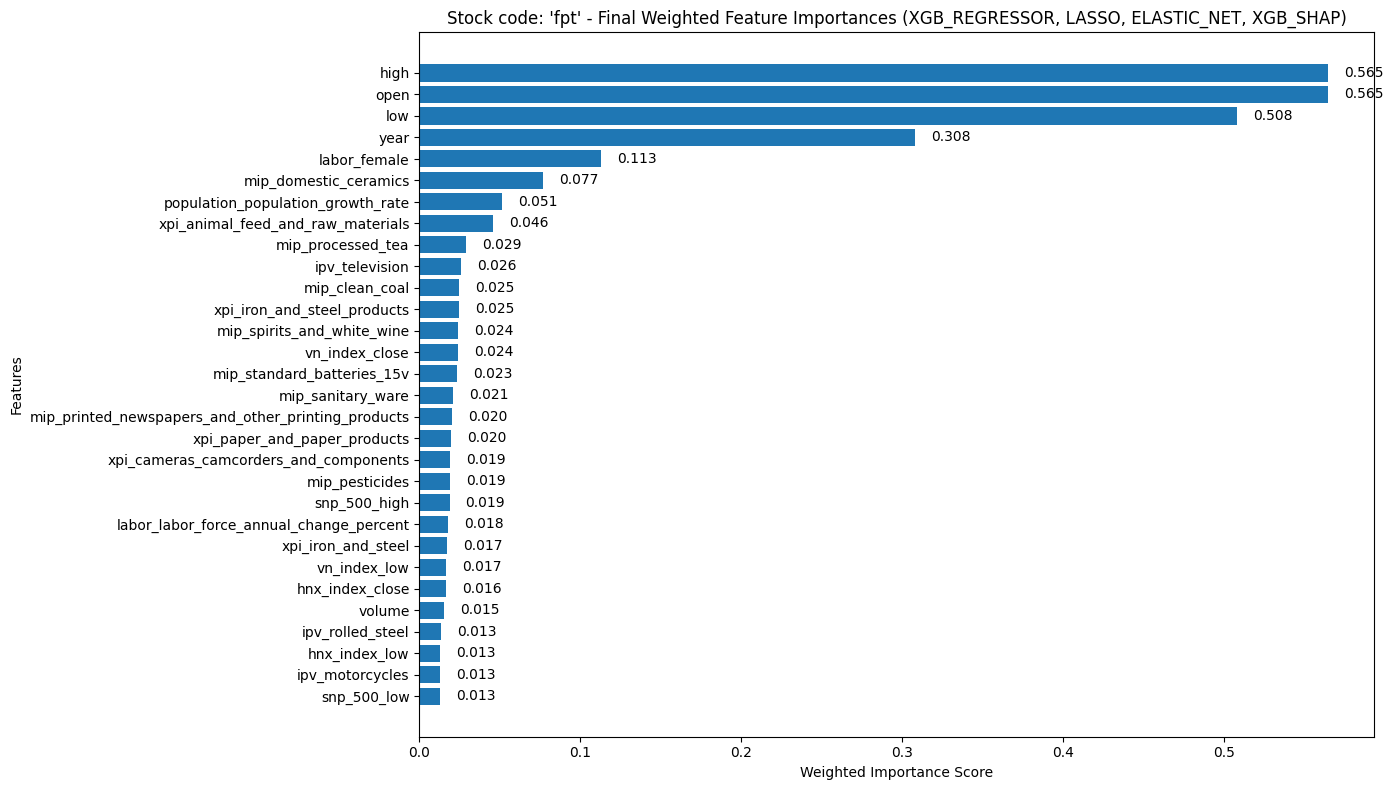

In [156]:
important_features_df = plot_final_feature_importances(
    stock_code=stock_code,
    combined_df=final_feature_importance_df,
    filename=f"{stock_code}_final_feature_importances.png",
    top_n=30,
)

In [157]:
important_features_df = get_important_features_df(
    combined_df=final_feature_importance_df,
    filename=f"{stock_code}_final_feature_importances.png",
    top_n=30,
)

In [158]:
important_features_df

,feature,final_importance
0,high,0.564582
1,open,0.564576
2,low,0.507589
3,year,0.307951
4,labor_female,0.112907
5,mip_domestic_ceramics,0.076838
6,population_population_growth_rate,0.051358
7,xpi_animal_feed_and_raw_materials,0.045771
8,mip_processed_tea,0.029086
9,ipv_television,0.025728


In [159]:
important_features_list = important_features_df["feature"].tolist()
important_features_list

['high',
 'open',
 'low',
 'year',
 'labor_female',
 'mip_domestic_ceramics',
 'population_population_growth_rate',
 'xpi_animal_feed_and_raw_materials',
 'mip_processed_tea',
 'ipv_television',
 'mip_clean_coal',
 'xpi_iron_and_steel_products',
 'mip_spirits_and_white_wine',
 'vn_index_close',
 'mip_standard_batteries_15v',
 'mip_sanitary_ware',
 'mip_printed_newspapers_and_other_printing_products',
 'xpi_paper_and_paper_products',
 'xpi_cameras_camcorders_and_components',
 'mip_pesticides',
 'snp_500_high',
 'labor_labor_force_annual_change_percent',
 'xpi_iron_and_steel',
 'vn_index_low',
 'hnx_index_close',
 'volume',
 'ipv_rolled_steel',
 'hnx_index_low',
 'ipv_motorcycles',
 'snp_500_low']

## Heatmap Visualization

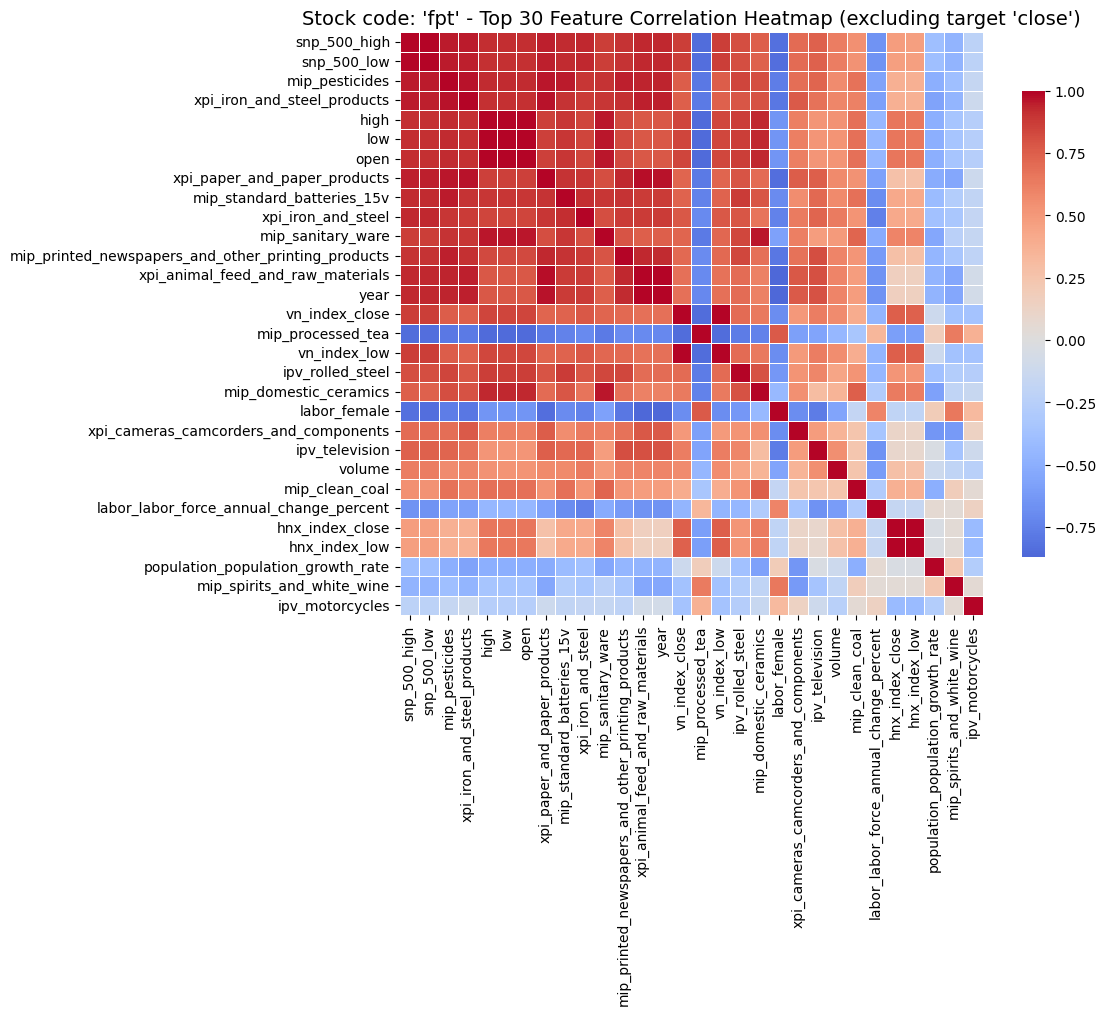

In [160]:
plot_feature_correlation_heatmap(
    stock_code=stock_code,
    df=train,
    feature_columns=important_features_list,
    target_column=output_column_name,
    top_corr_threshold=DEFAULT_CORRELATION_THRESHOLD,
)

## Correlation DataFrame

In [161]:
correlation_df = get_feature_correlation_df(
    df=train,
    feature_columns=important_features_list,
    target_column=output_column_name,
    top_corr_threshold=DEFAULT_CORRELATION_THRESHOLD,
)

In [162]:
correlation_df

,feature_1,feature_2,corr
0,low,open,0.999879
1,high,open,0.999853
2,snp_500_high,snp_500_low,0.999804
3,high,low,0.999801
4,vn_index_close,vn_index_low,0.999792
...,...,...,...
56,xpi_paper_and_paper_products,mip_standard_batteries_15v,0.904988
57,snp_500_high,mip_printed_newspapers_and_other_printing_prod...,0.904275
58,mip_standard_batteries_15v,mip_printed_newspapers_and_other_printing_prod...,0.902904
59,snp_500_low,mip_printed_newspapers_and_other_printing_prod...,0.902884


In [163]:
kept_features, dropped_features, pruned_importance_df = (
    drop_low_importance_correlated_features(
        important_features_df=important_features_df,
        correlation_df=correlation_df,
        corr_threshold=DEFAULT_CORRELATION_THRESHOLD,
    )
)

🔍 Dropped 14 highly correlated features (|r| > 0.9):
['hnx_index_low', 'low', 'mip_domestic_ceramics', 'mip_pesticides', 'mip_printed_newspapers_and_other_printing_products', 'mip_sanitary_ware', 'open', 'snp_500_high', 'snp_500_low', 'vn_index_low', 'xpi_animal_feed_and_raw_materials', 'xpi_iron_and_steel', 'xpi_iron_and_steel_products', 'xpi_paper_and_paper_products']
✅ Kept 16 features after pruning correlation redundancy.


In [164]:
kept_features

['high',
 'year',
 'labor_female',
 'population_population_growth_rate',
 'mip_processed_tea',
 'ipv_television',
 'mip_clean_coal',
 'mip_spirits_and_white_wine',
 'vn_index_close',
 'mip_standard_batteries_15v',
 'xpi_cameras_camcorders_and_components',
 'labor_labor_force_annual_change_percent',
 'hnx_index_close',
 'volume',
 'ipv_rolled_steel',
 'ipv_motorcycles']

In [165]:
dropped_features

['hnx_index_low',
 'low',
 'mip_domestic_ceramics',
 'mip_pesticides',
 'mip_printed_newspapers_and_other_printing_products',
 'mip_sanitary_ware',
 'open',
 'snp_500_high',
 'snp_500_low',
 'vn_index_low',
 'xpi_animal_feed_and_raw_materials',
 'xpi_iron_and_steel',
 'xpi_iron_and_steel_products',
 'xpi_paper_and_paper_products']

In [166]:
print(f"Dropped: {len(dropped_features)} features")

Dropped: 14 features


In [167]:
feature_selected_train = train.drop(columns=dropped_features)
feature_selected_train

,gdp_gdp_growth,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,xpi_confectionery_and_cereal_products,...,week_of_month,half_of_year,is_weekend,season,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,7.552055,2888.656452,92.003231,253.595161,16.025534,22.747446,11.056317,474.899933,747.464516,17.440706,...,2.0,2.0,0.0,1.0,-2.449294e-16,1.000000,0.974928,-0.222521,-0.304921,0.952378
1,7.553425,2898.413871,92.084006,265.067097,16.039604,22.767417,11.066024,475.316878,750.208710,17.456019,...,2.0,2.0,0.0,1.0,-2.449294e-16,1.000000,0.433884,-0.900969,-0.288482,0.957485
2,7.554795,2908.171290,92.164782,276.539032,16.053674,22.787388,11.075731,475.733823,752.952903,17.471331,...,3.0,2.0,0.0,1.0,-2.449294e-16,1.000000,-0.433884,-0.900969,-0.271958,0.962309
3,7.558904,2937.443548,92.407108,310.954839,16.095883,22.847303,11.104852,476.984656,761.185484,17.517268,...,3.0,2.0,0.0,1.0,-2.449294e-16,1.000000,0.000000,1.000000,-0.221922,0.975065
4,7.560274,2947.200968,92.487884,322.426774,16.109953,22.867274,11.114559,477.401601,763.929677,17.532580,...,3.0,2.0,0.0,1.0,-2.449294e-16,1.000000,0.781831,0.623490,-0.205104,0.978740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4135,4.463370,790.322581,409.677419,55.193548,194.193548,135.483871,225.806452,2932.258065,93.548387,110.355725,...,4.0,2.0,0.0,3.0,-5.000000e-01,-0.866025,0.781831,0.623490,-0.393590,-0.919286
4136,4.476304,791.935484,408.064516,55.161290,195.161290,132.903226,224.838710,2943.548387,91.290323,110.371038,...,4.0,2.0,0.0,3.0,-5.000000e-01,-0.866025,0.974928,-0.222521,-0.409356,-0.912375
4137,4.489239,793.548387,406.451613,55.129032,196.129032,130.322581,223.870968,2954.838710,89.032258,110.386350,...,4.0,2.0,0.0,3.0,-5.000000e-01,-0.866025,0.433884,-0.900969,-0.425000,-0.905193
4138,4.502174,795.161290,404.838710,55.096774,197.096774,127.741935,222.903226,2966.129032,86.774194,110.401662,...,4.0,2.0,0.0,3.0,-5.000000e-01,-0.866025,-0.433884,-0.900969,-0.440519,-0.897743


## Heatmap Visualization before + after feature selection

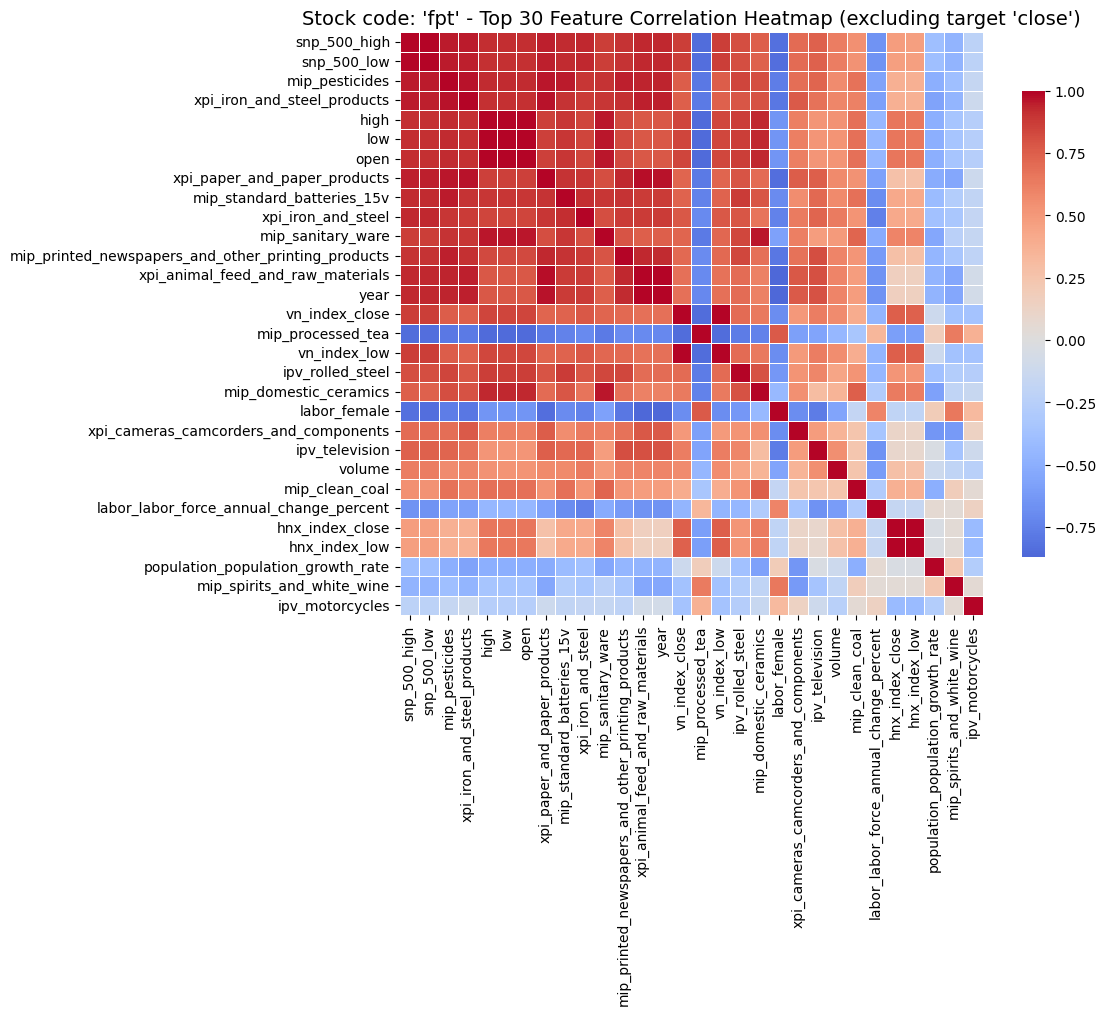

In [168]:
plot_feature_correlation_heatmap(
    stock_code=stock_code,
    df=train,
    feature_columns=important_features_list,
    target_column=output_column_name,
    top_corr_threshold=DEFAULT_CORRELATION_THRESHOLD,
)

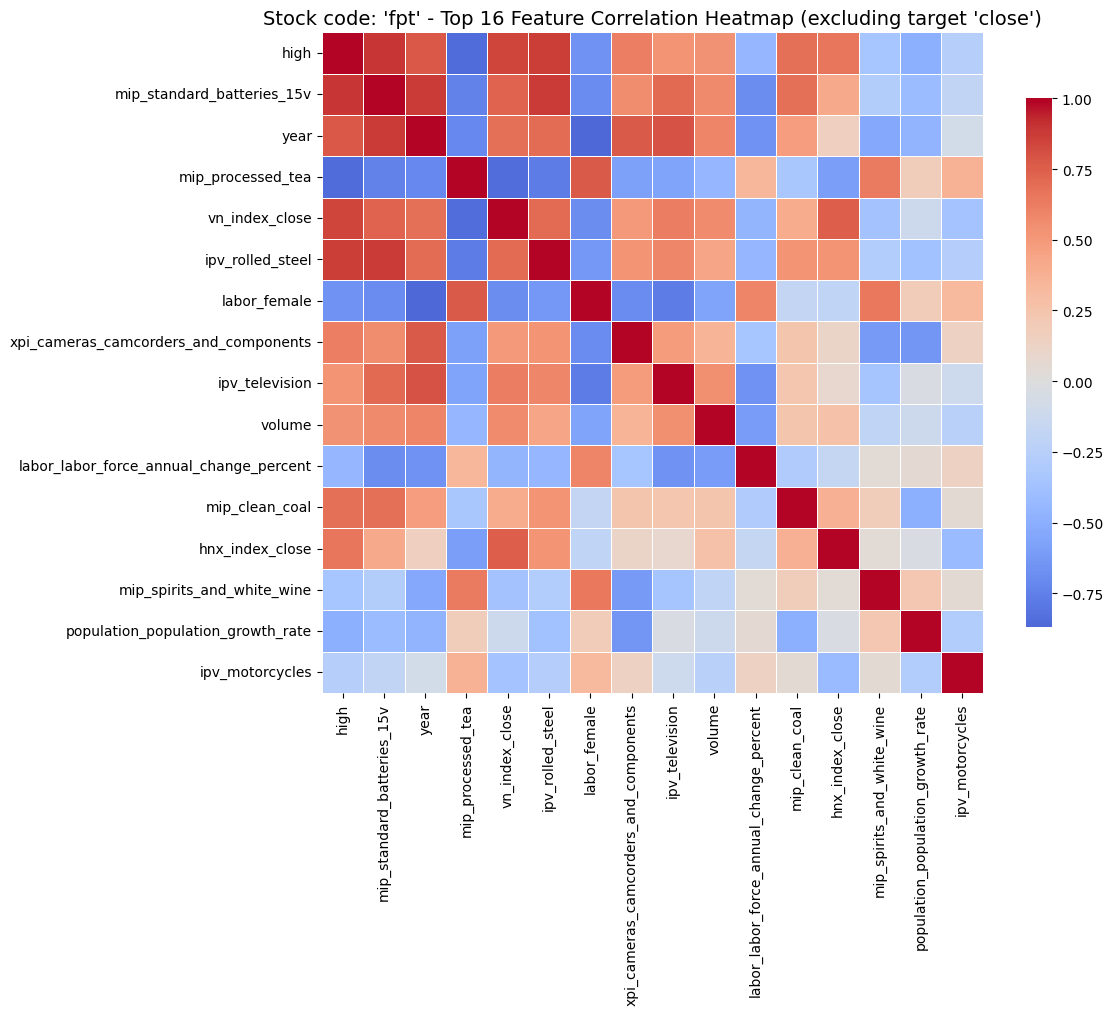

In [169]:
plot_feature_correlation_heatmap(
    stock_code=stock_code,
    df=feature_selected_train,
    feature_columns=kept_features,
    target_column=output_column_name,
    top_corr_threshold=DEFAULT_CORRELATION_THRESHOLD,
)

## Feature Selected train dataframe

In [170]:
feature_selected_train

,gdp_gdp_growth,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,xpi_confectionery_and_cereal_products,...,week_of_month,half_of_year,is_weekend,season,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,7.552055,2888.656452,92.003231,253.595161,16.025534,22.747446,11.056317,474.899933,747.464516,17.440706,...,2.0,2.0,0.0,1.0,-2.449294e-16,1.000000,0.974928,-0.222521,-0.304921,0.952378
1,7.553425,2898.413871,92.084006,265.067097,16.039604,22.767417,11.066024,475.316878,750.208710,17.456019,...,2.0,2.0,0.0,1.0,-2.449294e-16,1.000000,0.433884,-0.900969,-0.288482,0.957485
2,7.554795,2908.171290,92.164782,276.539032,16.053674,22.787388,11.075731,475.733823,752.952903,17.471331,...,3.0,2.0,0.0,1.0,-2.449294e-16,1.000000,-0.433884,-0.900969,-0.271958,0.962309
3,7.558904,2937.443548,92.407108,310.954839,16.095883,22.847303,11.104852,476.984656,761.185484,17.517268,...,3.0,2.0,0.0,1.0,-2.449294e-16,1.000000,0.000000,1.000000,-0.221922,0.975065
4,7.560274,2947.200968,92.487884,322.426774,16.109953,22.867274,11.114559,477.401601,763.929677,17.532580,...,3.0,2.0,0.0,1.0,-2.449294e-16,1.000000,0.781831,0.623490,-0.205104,0.978740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4135,4.463370,790.322581,409.677419,55.193548,194.193548,135.483871,225.806452,2932.258065,93.548387,110.355725,...,4.0,2.0,0.0,3.0,-5.000000e-01,-0.866025,0.781831,0.623490,-0.393590,-0.919286
4136,4.476304,791.935484,408.064516,55.161290,195.161290,132.903226,224.838710,2943.548387,91.290323,110.371038,...,4.0,2.0,0.0,3.0,-5.000000e-01,-0.866025,0.974928,-0.222521,-0.409356,-0.912375
4137,4.489239,793.548387,406.451613,55.129032,196.129032,130.322581,223.870968,2954.838710,89.032258,110.386350,...,4.0,2.0,0.0,3.0,-5.000000e-01,-0.866025,0.433884,-0.900969,-0.425000,-0.905193
4138,4.502174,795.161290,404.838710,55.096774,197.096774,127.741935,222.903226,2966.129032,86.774194,110.401662,...,4.0,2.0,0.0,3.0,-5.000000e-01,-0.866025,-0.433884,-0.900969,-0.440519,-0.897743
